In [15]:
!pip install typing spacy matplotlib textdescriptives ripser transformers accelerate torch numpy pandas tqdm networkx hf_transfer datasets seaborn pyarrow fastparquet datasets
!python -m spacy download en_core_web_sm
!pip install dcor
!pip install torch>=2.6.0


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [27]:
import os
os.environ["HF_HOME"] = "/workspace/huggingface"
os.environ["HF_DATASETS_CACHE"] = "/workspace/huggingface/datasets"

In [28]:
!rm -rf ~/.cache/huggingface/hub/datasets--snli
!rm -rf ~/.cache/huggingface/hub/datasets--multi_nli

In [2]:
!mv ~/.cache/huggingface/hub/models--meta-llama--Llama-3.1-8B-Instruct /workspace/
!ln -s /workspace/models--meta-llama--Llama-3.1-8B-Instruct ~/.cache/huggingface/hub/models--meta-llama--Llama-3.1-8B-Instruct

In [3]:
!df -h /
!du -sh ~/.cache/huggingface/hub/models--meta-llama--Llama-3.1-8B-Instruct

Filesystem      Size  Used Avail Use% Mounted on
overlay          20G  5.1G   15G  26% /
0	/root/.cache/huggingface/hub/models--meta-llama--Llama-3.1-8B-Instruct


In [26]:
import sys
!{sys.executable} -m pip uninstall -y typing_extensions
!{sys.executable} -m pip install --no-cache-dir typing_extensions

Found existing installation: typing_extensions 4.15.0
Uninstalling typing_extensions-4.15.0:
  Successfully uninstalled typing_extensions-4.15.0
ERROR: Could not install packages due to an OSError: [Errno 28] No space left on device: '/usr/local/lib/python3.11/dist-packages/typing_extensions-4.15.0.dist-info'


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [5]:
from huggingface_hub import login
login()

In [6]:
import torch
from transformers import (
    BertTokenizer, 
    BertModel,
    GPT2Tokenizer,
    GPT2Model,
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModel
)
import numpy as np
import pandas as pd
import ripser
from ripser import ripser
from tqdm import tqdm
import math
import numpy as geek
import networkx as nx
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Optional, List, Tuple
import spacy
import textdescriptives as td
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import dcor
from typing import Dict, List, Optional, Tuple

In [7]:
# ============================================================================
# TDA COMPUTATION FUNCTIONS
# ============================================================================

def find_highest_finite_value_comprehension(data):
    """Finds the highest value in a list, ignoring inf values, using list comprehension."""
    finite_values = [x for x in data if not math.isinf(x)]
    return max(finite_values) if finite_values else -math.inf

def get_second_value_ignoring_inf(data):
    """
    Returns the second non-inf value in a list.

    Args:
      data: A list of numerical values.

    Returns:
      The second non-inf value in the list, or None if not found.
    """
    non_inf_values = [x for x in data if not math.isinf(x)]
    if len(non_inf_values) < 2:
        return None
    return non_inf_values[1]

def get_encoder_attention(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, 
                      padding=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
        
    attention = torch.stack(outputs.attentions)
    attention = attention.mean(dim=0).mean(dim=1).squeeze()
    
    return attention.float().cpu().numpy()

def get_electra_attention(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors='pt', truncation=True,
                      padding=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    
    attention = torch.stack(outputs.attentions)
    attention = attention.mean(dim=0).mean(dim=1).squeeze()
    attention = attention.float().cpu().numpy()
    
    attention = np.clip(attention, 0, np.percentile(attention, 95))
    
    return attention

def get_gpt_attention(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors='pt', truncation=True,
                      max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    
    attention = torch.stack(outputs.attentions)
    attention = attention.mean(dim=0).mean(dim=1).squeeze()
    attention = attention.float().cpu().numpy()
    
    attention[0, :] = 0
    attention[:, 0] = 0
    
    return attention

def get_llama_attention(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors='pt', truncation=True,
                      max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    n_kv_groups = model.config.num_key_value_heads
    attention_layers = torch.stack(outputs.attentions)  
    
    n_heads = model.config.num_attention_heads
    group_size = n_heads // n_kv_groups
    
    attention_layers = attention_layers.view(
        attention_layers.shape[0], attention_layers.shape[1],
        n_kv_groups, group_size,
        attention_layers.shape[3], attention_layers.shape[4]
    )
    attention = attention_layers.mean(dim=3).mean(dim=2).mean(dim=0).squeeze()
    attention = attention.float().cpu().numpy()
    
    attention[0, :] = 0
    attention[:, 0] = 0
    
    return attention

def get_qwen_attention(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors='pt', truncation=True,
                      max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    
    n_kv_groups = model.config.num_key_value_heads
    attention_layers = torch.stack(outputs.attentions)
    
    n_heads = model.config.num_attention_heads
    group_size = n_heads // n_kv_groups
    
    attention_layers = attention_layers.view(
        attention_layers.shape[0], attention_layers.shape[1],
        n_kv_groups, group_size,
        attention_layers.shape[3], attention_layers.shape[4]
    )
    attention = attention_layers.mean(dim=3).mean(dim=2).mean(dim=0).squeeze()
    attention = attention.float().cpu().numpy()
    
    attention[0, :] = 0
    attention[:, 0] = 0
    
    return attention
    
def build_graph(attention_matrix, causal=False):
    positive_vals = attention_matrix[attention_matrix > 0]
    if len(positive_vals) == 0:
        threshold = 0.0
    else:
        threshold = np.percentile(positive_vals, 80)
    
    if causal:
        graph = nx.DiGraph()
        num_nodes = attention_matrix.shape[0]
        for i in range(num_nodes):
            for j in range(num_nodes):
                if attention_matrix[i, j] > threshold:
                    graph.add_edge(i, j, weight=attention_matrix[i, j])
    else:
        graph = nx.Graph()
        num_nodes = attention_matrix.shape[0]
        for i in range(num_nodes):
            for j in range(i + 1, num_nodes):
                if attention_matrix[i, j] > threshold:
                    graph.add_edge(i, j, weight=attention_matrix[i, j])
    
    return graph

def compute_tda_features(graph):
    adjacency_matrix = nx.to_scipy_sparse_array(graph, format='csr')
    diagrams = ripser(adjacency_matrix, maxdim=1)['dgms']
    
    h0 = diagrams[0]
    h1 = diagrams[1] if (len(diagrams) > 1 and len(diagrams[1]) > 0) else None

    # --- H0 features ---
    persistences_h0 = h0[:, 1] - h0[:, 0]
    finite_mask_h0 = np.isfinite(persistences_h0)
    h0_finite = persistences_h0[finite_mask_h0]
    h0_persistences = np.sort(h0_finite)

    num_h0 = len(h0_finite)
    highest_h0 = h0_persistences[-1] if num_h0 > 0 else 0
    second_highest_h0 = h0_persistences[-2] if num_h0 > 1 else 0
    highest_minus_second_h0 = highest_h0 - second_highest_h0 if num_h0 > 1 else 0
    mean_h0 = np.mean(h0_persistences) if num_h0 > 0 else 0
    sum_persistence_0 = np.sum(h0_persistences) if num_h0 > 0 else 0
    persistence_entropy_0 = (
        -np.sum(h0_persistences * np.log(h0_persistences + 1e-10)) 
        if num_h0 > 0 else 0
    )

    # --- H1 features ---
    if h1 is not None:
        persistences_h1 = h1[:, 1] - h1[:, 0]
        finite_mask_h1 = np.isfinite(persistences_h1)
        h1_finite = persistences_h1[finite_mask_h1]
        h1_persistences = np.sort(h1_finite)

        num_h1 = len(h1_finite)
        highest_h1 = h1_persistences[-1] if num_h1 > 0 else 0
        second_highest_h1 = h1_persistences[-2] if num_h1 > 1 else 0
        highest_minus_second_h1 = highest_h1 - second_highest_h1 if num_h1 > 1 else 0
        mean_h1 = np.mean(h1_persistences) if num_h1 > 0 else 0
        sum_persistence_1 = np.sum(h1_persistences) if num_h1 > 0 else 0
        persistence_entropy_1 = (
            -np.sum(h1_persistences * np.log(h1_persistences + 1e-10))
            if num_h1 > 0 else 0
        )
    else:
        num_h1 = highest_h1 = highest_minus_second_h1 = mean_h1 = 0
        sum_persistence_1 = persistence_entropy_1 = 0

    return [num_h0, highest_h0, highest_minus_second_h0, mean_h0, 
            sum_persistence_0, persistence_entropy_0,
            num_h1, highest_h1, highest_minus_second_h1, mean_h1,
            sum_persistence_1, persistence_entropy_1]

def load_model(model_type, model_path, device='cuda'):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    
    if model_type == 'bert' or model_type == 'electra':
        model = AutoModel.from_pretrained(
            model_path,
            attn_implementation="eager",
            torch_dtype=torch.float16 if device == 'cuda' else torch.float32
        )
    else:  # gpt, llama, qwen
        model = AutoModelForCausalLM.from_pretrained(
            model_path,
            attn_implementation="eager",
            torch_dtype=torch.float16 if device == 'cuda' else torch.float32
        )
    
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    model.config.pad_token_id = tokenizer.pad_token_id
    model = model.to(device)
    model.eval()
    return model, tokenizer


def process_texts(texts, model_type, model, tokenizer):
    
    attention_funcs = {
        'bert':    get_encoder_attention,
        'electra': get_electra_attention,
        'gpt':     get_gpt_attention,
        'llama':   get_llama_attention,
        'qwen':    get_qwen_attention,
    }
    
    causal_models = {'gpt', 'llama', 'qwen'}
    
    attention_func = attention_funcs[model_type]
    causal = model_type in causal_models
    
    data = []
    for text in tqdm(texts):
        attention_matrix = attention_func(text, model, tokenizer)
        graph = build_graph(attention_matrix, causal=causal)
        tda_features = compute_tda_features(graph)
        data.append(tda_features)
        
        # clear gpu cache between sentences for large models
        if model_type in {'llama', 'qwen'}:
            torch.cuda.empty_cache()
    
    columns = ["Num_0dim", "Max_0dim", "Max_0dim_Minus_Second", "Mean_0dim", 
           "sum_persistence_0", "persistence_entropy_0",
           "Num_1dim", "Max_1dim", "Max_1dim_Minus_Second", "Mean_1dim", 
           "sum_persistence_1", "persistence_entropy_1"]
    
    return pd.DataFrame(data, columns=columns)

In [8]:
# ============================================================================
# LINGUISTIC FEATURE EXTRACTION
# ============================================================================

nlp = spacy.load("en_core_web_sm")
if "textdescriptives/all" not in nlp.pipe_names:
    nlp.add_pipe("textdescriptives/all")

def extract_linguistic_features(texts: pd.Series) -> pd.DataFrame:
    results = []
    for text in tqdm(texts, desc="Extracting linguistic features"):
        try:
            doc = nlp(text)
            features = td.extract_df(doc)
            results.append(features.iloc[0])
        except Exception as e:
            print(f"Error processing text: {e}")
            if results:
                results.append(pd.Series(np.nan, index=results[0].index))
            else:
                results.append(pd.Series())
    
    return pd.concat(results, axis=1).T.reset_index(drop=True)

In [9]:
# ============================================================================
# CORRELATION ANALYSIS
# ============================================================================

def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
    
    bad_cols = df_clean.columns[df_clean.isna().all()].tolist()
    if bad_cols:
        print(f"Warning: these columns are entirely NaN and will be zeroed: {bad_cols}")
    
    df_clean = df_clean.fillna(df_clean.mean())
    df_clean = df_clean.fillna(0)
    df_clean = df_clean.astype(float)
    return df_clean

def compute_dcor_matrix(tda_data, linguistic_data):
    
    tda_clean = clean_data(tda_data)
    ling_clean = clean_data(linguistic_data)
    
    tda_features = tda_clean.to_numpy()
    linguistic_features = ling_clean.to_numpy()
    
    corr_matrix = np.zeros((tda_features.shape[1], linguistic_features.shape[1]))
    for i in range(tda_features.shape[1]):
        for j in range(linguistic_features.shape[1]):
            try:
                corr_matrix[i, j] = dcor.distance_correlation(tda_features[:, i], linguistic_features[:, j])
            except Exception as e:
                print(f"Warning: Could not compute correlation for indices ({i}, {j}): {e}")
                corr_matrix[i, j] = 0.0
    
    return corr_matrix

In [10]:
# ==================
# FEATURE CATEGORIES 
# ==================

FEATURE_CATEGORIES = {
    'descriptive_statistics': [
        'token_length_mean', 'token_length_median', 'token_length_std',
        'sentence_length_mean', 'sentence_length_median', 'sentence_length_std',
        'syllables_per_token_mean', 'syllables_per_token_median', 'syllables_per_token_std',
        'n_tokens', 'n_unique_tokens', 'proportion_unique_tokens', 
        'n_characters'
    ],
    'quality': [
        'n_stop_words', 'alpha_ratio', 'mean_word_length', 'doc_length', 
        'proportion_ellipsis', 'proportion_bullet_points', 'symbol_to_word_ratio_#', 
        'contains_lorem ipsum', 'passed_quality_check', 'oov_ratio'
    ],
    'information_theory': [
        'entropy', 'perplexity', 'per_word_perplexity'
    ]
}

DEFAULT_TDA_FEATURES = [
    "Num_0dim", "Max_0dim", "Max_0dim_Minus_Second", "Mean_0dim", 
    "sum_persistence_0", "persistence_entropy_0",
    "Num_1dim", "Max_1dim", "Max_1dim_Minus_Second", "Mean_1dim",
    "sum_persistence_1", "persistence_entropy_1"
]

def drop_low_variance_cols(df: pd.DataFrame, threshold: float = 1e-6) -> pd.DataFrame:
    variances = df.apply(pd.to_numeric, errors='coerce').var()
    keep = variances[variances > threshold].index.tolist()
    dropped = [c for c in df.columns if c not in keep]
    if dropped:
        print(f"Dropped low-variance columns: {dropped}")
    return df[keep]

# ============================================================================
# ANALYSIS 1 — BLiMP: good vs bad sentences
# ============================================================================

def analyze_blimp(blimp_config: str,
                  model_type: str,
                  model,
                  tokenizer,
                  n_samples: int = 500,
                  output_pdf: str = "blimp_analysis.pdf",
                  tda_features: Optional[List[str]] = None):

    if os.path.exists(output_pdf):
        print(f"  → skipping [{blimp_config}] — already exists")
        return None
    
    if tda_features is None:
        tda_features = DEFAULT_TDA_FEATURES

    print("="*60)
    print(f"Analysis 1: BLiMP Good vs Bad")
    print(f"Config: {blimp_config} | Model type: {model_type}")
    print("="*60)

    # load dataset
    print("\n1. Loading BLiMP dataset...")
    ds = load_dataset("blimp", blimp_config, split="train")
    df = ds.to_pandas()

    good_sentences = df["sentence_good"].head(n_samples)
    bad_sentences  = df["sentence_bad"].head(n_samples)
    print(f"Loaded {len(good_sentences)} sentence pairs")

    # TDA features
    print("\n2. Extracting TDA features...")
    good_tda = process_texts(good_sentences.tolist(), model_type, model, tokenizer)
    bad_tda  = process_texts(bad_sentences.tolist(),  model_type, model, tokenizer)

    # linguistic features
    print("\n3. Extracting linguistic features...")
    good_ling = extract_linguistic_features(good_sentences)
    bad_ling  = extract_linguistic_features(bad_sentences)

    good_ling = drop_low_variance_cols(extract_linguistic_features(good_sentences))
    bad_ling  = drop_low_variance_cols(extract_linguistic_features(bad_sentences))

    results = {
        'good': {'tda': good_tda, 'linguistic': good_ling},
        'bad':  {'tda': bad_tda,  'linguistic': bad_ling}
    }

    # generate heatmaps
    print("\n4. Computing correlations and generating heatmaps...")
    with PdfPages(output_pdf) as pdf:
        for category, features in FEATURE_CATEGORIES.items():
            print(f"\nProcessing category: {category}")

            # check which features are actually available
            available_features = [
                f for f in features 
                if f in good_ling.columns and f in bad_ling.columns
            ]
            if not available_features:
                print(f"No features available for {category}, skipping...")
                continue

            for label, data in results.items():
                ling_data = data['linguistic'][available_features].apply(
                    pd.to_numeric, errors='coerce'
                ).dropna(axis=1, how='all')

                if ling_data.empty:
                    continue

                tda_data = data['tda'][tda_features]

                # correlation heatmap
                corr_matrix = compute_dcor_matrix(tda_data, ling_data)
                fig = plot_category_heatmap(
                    corr_matrix, tda_features, ling_data.columns.tolist(),
                    f"BLiMP {blimp_config} — {label.title()} "
                    f"— {category.replace('_', ' ').title()}"
                )
                pdf.savefig(fig, bbox_inches='tight')
                plt.close(fig)

                # p-value heatmap with correction
                pval_matrix = compute_pval_matrix(tda_data, ling_data)
                pval_matrix = correct_pval_matrix(pval_matrix)
                fig_pval = plot_pval_heatmap(
                    pval_matrix, tda_features, ling_data.columns.tolist(),
                    f"BLiMP {blimp_config} — {label.title()} "
                    f"— {category.replace('_', ' ').title()} (p-values, FDR corrected)"
                )
                pdf.savefig(fig_pval, bbox_inches='tight')
                plt.close(fig_pval)

            # difference heatmap: good minus bad
            good_ling_data = results['good']['linguistic'][available_features].apply(
                pd.to_numeric, errors='coerce').dropna(axis=1, how='all')
            bad_ling_data = results['bad']['linguistic'][available_features].apply(
                pd.to_numeric, errors='coerce').dropna(axis=1, how='all')

            if not good_ling_data.empty and not bad_ling_data.empty:
                common_cols = list(
                    set(good_ling_data.columns) & set(bad_ling_data.columns)
                )
                if common_cols:
                    corr_good = compute_dcor_matrix(
                        results['good']['tda'][tda_features], 
                        good_ling_data[common_cols]
                    )
                    corr_bad = compute_dcor_matrix(
                        results['bad']['tda'][tda_features],  
                        bad_ling_data[common_cols]
                    )
                    fig_diff = plot_difference_heatmap(
                        corr_good, corr_bad,
                        tda_features, common_cols,
                        f"BLiMP {blimp_config} — Good minus Bad "
                        f"— {category.replace('_', ' ').title()}"
                    )
                    pdf.savefig(fig_diff, bbox_inches='tight')
                    plt.close(fig_diff)

    print(f"\nAnalysis 1 complete. Saved to: {output_pdf}")
    return results


# ============================================================================
# ANALYSIS 2 — SNLI/MultiNLI: label comparison
# ============================================================================

def analyze_nli(dataset_name: str,
                dataset_config: str,
                model_type: str,
                model,
                tokenizer,
                n_samples: int = 500,
                output_pdf: str = "nli_analysis.pdf",
                tda_features: Optional[List[str]] = None):

    if os.path.exists(output_pdf):
        print(f"  → skipping [{dataset_name}] — already exists")
        return None
    
    if tda_features is None:
        tda_features = DEFAULT_TDA_FEATURES

    # SNLI/MultiNLI label mapping
    label_names = {0: 'entailment', 1: 'neutral', 2: 'contradiction'}

    print("="*60)
    print(f"Analysis 2: NLI Label Comparison")
    print(f"Dataset: {dataset_name}/{dataset_config} | Model type: {model_type}")
    print("="*60)

    print("\n1. Loading dataset...")
    ds = load_dataset(dataset_name, dataset_config, split="train")
    df = ds.to_pandas()

    # SNLI has some unlabeled rows with label=-1
    df = df[df["label"] != -1]

    results = {}
    for label_val, label_name in label_names.items():
        subset = df[df["label"] == label_val]["premise"].head(n_samples)
        if len(subset) == 0:
            print(f"No samples found for label {label_name}, skipping...")
            continue

        print(f"\n{'='*60}")
        print(f"Processing: {label_name} ({len(subset)} samples)")
        print(f"{'='*60}")

        print("  Extracting TDA features...")
        tda_df = process_texts(subset.tolist(), model_type, model, tokenizer)

        print("  Extracting linguistic features...")
        ling_df = extract_linguistic_features(subset)

        results[label_name] = {'tda': tda_df, 'linguistic': ling_df}

    print("\n2. Computing correlations and generating heatmaps...")
    with PdfPages(output_pdf) as pdf:
        for category, features in FEATURE_CATEGORIES.items():
            print(f"\nProcessing category: {category}")

            # check feature availability across all labels
            sample_ling = list(results.values())[0]['linguistic']
            available_features = [f for f in features if f in sample_ling.columns]
            if not available_features:
                print(f"No features available for {category}, skipping...")
                continue

            # per-label correlation and p-value heatmaps
            corr_matrices = {}
            for label_name, data in results.items():
                ling_data = data['linguistic'][available_features].apply(
                    pd.to_numeric, errors='coerce'
                ).dropna(axis=1, how='all')

                if ling_data.empty:
                    continue

                tda_data = data['tda'][tda_features]

                corr_matrix = compute_dcor_matrix(tda_data, ling_data)
                corr_matrices[label_name] = (corr_matrix, ling_data.columns.tolist())

                fig = plot_category_heatmap(
                    corr_matrix, tda_features, ling_data.columns.tolist(),
                    f"{dataset_name.upper()} — {label_name.title()} "
                    f"— {category.replace('_', ' ').title()}"
                )
                pdf.savefig(fig, bbox_inches='tight')
                plt.close(fig)

                pval_matrix = compute_pval_matrix(tda_data, ling_data)
                pval_matrix = correct_pval_matrix(pval_matrix)
                fig_pval = plot_pval_heatmap(
                    pval_matrix, tda_features, ling_data.columns.tolist(),
                    f"{dataset_name.upper()} — {label_name.title()} "
                    f"— {category.replace('_', ' ').title()} (p-values, FDR corrected)"
                )
                pdf.savefig(fig_pval, bbox_inches='tight')
                plt.close(fig_pval)

            # difference heatmaps for each label pair
            label_list = list(corr_matrices.keys())
            for i in range(len(label_list)):
                for j in range(i + 1, len(label_list)):
                    label_a, label_b = label_list[i], label_list[j]
                    corr_a, cols_a = corr_matrices[label_a]
                    corr_b, cols_b = corr_matrices[label_b]

                    common_cols = list(set(cols_a) & set(cols_b))
                    if not common_cols:
                        continue

                    # re-index to common columns
                    idx_a = [cols_a.index(c) for c in common_cols]
                    idx_b = [cols_b.index(c) for c in common_cols]

                    fig_diff = plot_difference_heatmap(
                        corr_a[:, idx_a], corr_b[:, idx_b],
                        tda_features, common_cols,
                        f"{dataset_name.upper()} — {label_a.title()} minus "
                        f"{label_b.title()} — {category.replace('_', ' ').title()}"
                    )
                    pdf.savefig(fig_diff, bbox_inches='tight')
                    plt.close(fig_diff)

    print(f"\nAnalysis 2 complete. Saved to: {output_pdf}")
    return results

In [11]:
!pip install statsmodels
from statsmodels.stats.multitest import multipletests

HEATMAP_W = 14
HEATMAP_H = 6

def _format_heatmap_ax(ax, title):
    ax.set_title(title, fontsize=10, pad=10)
    ax.set_xticklabels(
        [t.get_text() for t in ax.get_xticklabels()],
        rotation=40, ha='right', fontsize=7
    )
    ax.set_yticklabels(
        [t.get_text() for t in ax.get_yticklabels()],
        rotation=0, fontsize=7
    )

def compute_pval_matrix(tda_data, linguistic_data):
    tda_clean = clean_data(tda_data)
    ling_clean = clean_data(linguistic_data)
    
    tda_features = tda_clean.to_numpy()
    linguistic_features = ling_clean.to_numpy()
    
    n = tda_features.shape[0]
    if n < 30:
        print(f"Warning: only {n} samples — p-values unreliable")
    
    pval_matrix = np.zeros((tda_features.shape[1], linguistic_features.shape[1]))
    
    for i in range(tda_features.shape[1]):
        for j in range(linguistic_features.shape[1]):
            try:
                result = dcor.independence.distance_correlation_t_test(
                    tda_features[:, i],
                    linguistic_features[:, j]
                )
                pval_matrix[i, j] = result.pvalue
            except Exception as e:
                print(f"Warning: Could not compute p-value ({i}, {j}): {e}")
                pval_matrix[i, j] = 1.0
    
    return pval_matrix

def plot_difference_heatmap(corr_good, corr_bad,
                             tda_feature_names, linguistic_feature_names, title):
    diff = corr_good - corr_bad
    fig, ax = plt.subplots(figsize=(HEATMAP_W, HEATMAP_H))
    sns.heatmap(diff, annot=True, cmap="RdBu_r", fmt='.2f',
                center=0, vmin=-1, vmax=1,
                xticklabels=linguistic_feature_names,
                yticklabels=tda_feature_names,
                annot_kws={'size': 7},
                linewidths=0.3, linecolor='lightgrey', ax=ax)
    _format_heatmap_ax(ax, title)
    plt.tight_layout()
    return fig

def correct_pval_matrix(pval_matrix: np.ndarray, method: str = 'fdr_bh') -> np.ndarray:
    original_shape = pval_matrix.shape
    pvals_flat = pval_matrix.flatten()
    
    _, pvals_corrected, _, _ = multipletests(pvals_flat, method=method)
    corrected = pvals_corrected.reshape(original_shape)
    
    n_significant = np.sum(corrected < 0.05)
    n_total = corrected.size
    print(f"After {method} correction: {n_significant}/{n_total} pairs significant at p<0.05")
    
    return corrected

def plot_category_heatmap(corr_matrix, tda_feature_names,
                          linguistic_feature_names, title):
    fig, ax = plt.subplots(figsize=(HEATMAP_W, HEATMAP_H))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='.2f',
                xticklabels=linguistic_feature_names,
                yticklabels=tda_feature_names,
                vmin=0, vmax=1, ax=ax,
                annot_kws={'size': 7},
                linewidths=0.3, linecolor='lightgrey')
    _format_heatmap_ax(ax, title)
    plt.tight_layout()
    return fig

def plot_pval_heatmap(pval_matrix, tda_feature_names,
                      linguistic_feature_names, title):
    fig, ax = plt.subplots(figsize=(HEATMAP_W, HEATMAP_H))
    sns.heatmap(pval_matrix, annot=True, cmap="coolwarm_r", fmt='.3f',
                xticklabels=linguistic_feature_names,
                yticklabels=tda_feature_names,
                vmin=0, vmax=1, ax=ax,
                annot_kws={'size': 7},
                linewidths=0.3, linecolor='lightgrey')
    sig_mask = pval_matrix >= 0.05
    sns.heatmap(pval_matrix, mask=~sig_mask, annot=False,
                cmap=sns.color_palette(["lightgrey"], as_cmap=True),
                vmin=0, vmax=1, ax=ax, cbar=False,
                xticklabels=linguistic_feature_names,
                yticklabels=tda_feature_names)
    _format_heatmap_ax(ax, f"{title} — grey = p≥0.05")
    plt.tight_layout()
    return fig


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip



Loading bert-base-uncased...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[1/96] BLiMP-anaphor_gender_agreement | bert-base-uncased
  → skipping [anaphor_gender_agreement] — already exists
  ✓ Saved to tda_linguistic_results/blimp_anaphor_gender_agreement_bert-base-uncased.pdf
[2/96] BLiMP-anaphor_number_agreement | bert-base-uncased
  → skipping [anaphor_number_agreement] — already exists
  ✓ Saved to tda_linguistic_results/blimp_anaphor_number_agreement_bert-base-uncased.pdf
[3/96] BLiMP-distractor_agreement_relative_clause | bert-base-uncased
  → skipping [distractor_agreement_relative_clause] — already exists
  ✓ Saved to tda_linguistic_results/blimp_distractor_agreement_relative_clause_bert-base-uncased.pdf
[4/96] BLiMP-distractor_agreement_relational_noun | bert-base-uncased
  → skipping [distractor_agreement_relational_noun] — already exists
  ✓ Saved to tda_linguistic_results/blimp_distractor_agreement_relational_noun_bert-base-uncased.pdf
[5/96] BLiMP-irregular_past_participle_verbs | bert-base-uncased
  → skipping [irregular_past_participle_verbs] 

...

  0%|          | 0/500 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/ripser/ripser.py:251: UserWarning: The input matrix is square, but the distance_matrix flag is off.  Did you mean to indicate that this was a distance matrix?
  warnings.warn(
100%|██████████| 500/500 [00:05<00:00, 97.01it/s]


  Extracting linguistic features...


Extracting linguistic features: 100%|██████████| 500/500 [00:04<00:00, 107.82it/s]



2. Computing correlations and generating heatmaps...

Processing category: descriptive_statistics
After fdr_bh correction: 139/156 pairs significant at p<0.05
After fdr_bh correction: 139/156 pairs significant at p<0.05


KeyboardInterrupt: 

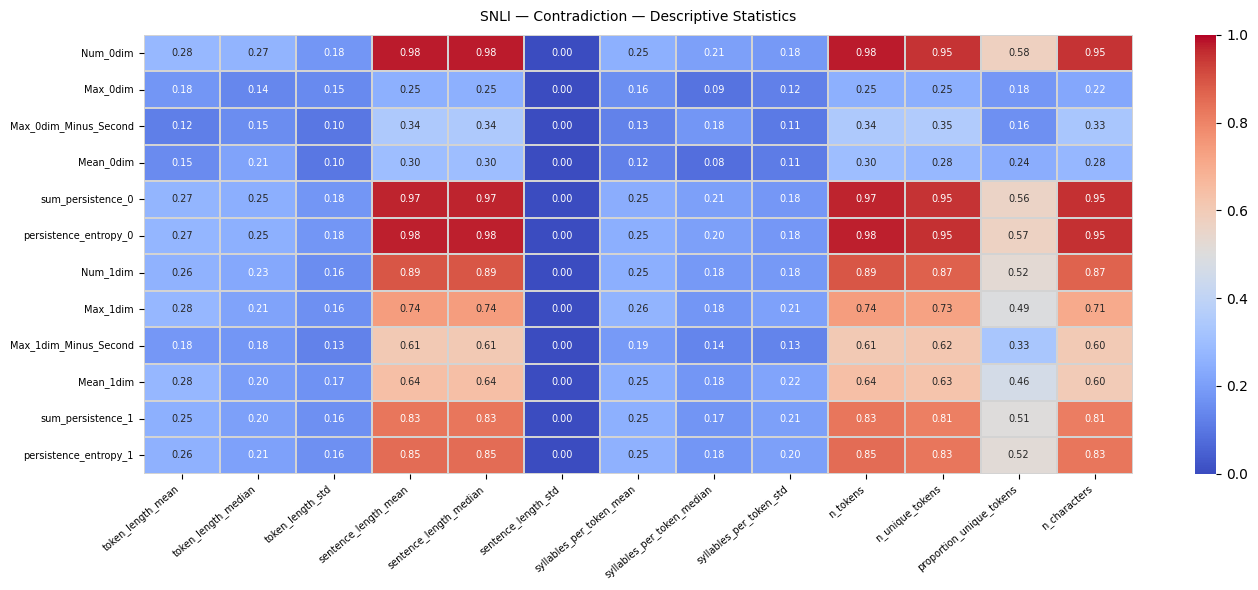

In [12]:
if __name__ == "__main__":
    import os
    import gc
    from datetime import datetime

    encoder_models = {
        "bert-base-uncased":       {"type": "bert",    "path": "bert-base-uncased"},
        "roberta-base":            {"type": "bert",    "path": "roberta-base"},
        "distilbert-base-uncased": {"type": "bert",    "path": "distilbert-base-uncased"},
        "electra-small":           {"type": "electra", "path": "google/electra-small-discriminator"},
    }

    decoder_models = {
        "gpt2":                    {"type": "gpt",   "path": "gpt2"},
        "distilgpt2":              {"type": "gpt",   "path": "distilgpt2"},
        "llama-3.1-8b-instruct":   {"type": "llama", "path": "meta-llama/Llama-3.1-8B-Instruct"},
        "qwen-2.5-7b-instruct":    {"type": "qwen",  "path": "Qwen/Qwen2.5-7B-Instruct"},
    }

    # Analysis 1 — BLiMP subcategories
    blimp_configs = [
        # anaphor agreement — split into two
        "anaphor_gender_agreement",
        "anaphor_number_agreement",
        
        # distractor agreement — these exist as named
        "distractor_agreement_relative_clause",
        "distractor_agreement_relational_noun",
        
        # irregular morphology
        "irregular_past_participle_verbs",
        "irregular_plural_subject_verb_agreement_1",
        
        # wh-questions — clean comparison pair
        "wh_questions_subject_gap",
        "wh_questions_object_gap",
        
        # island constraints
        "wh_island",
        "complex_NP_island",
    ]

    # Analysis 2 — NLI datasets
    nli_datasets = [
        {"name": "snli",      "config": "plain_text", "description": "SNLI"},
        {"name": "multi_nli", "config": "plain_text", "description": "MultiNLI"},
    ]

    # sample size: use smaller n for large decoder models to avoid OOM
    N_SAMPLES_ENCODER = 500
    N_SAMPLES_DECODER = 200

    results_dir = "tda_linguistic_results"
    os.makedirs(results_dir, exist_ok=True)

    log_file = os.path.join(
        results_dir, 
        f"run_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
    )

    def clear_memory(model):
        del model
        torch.cuda.empty_cache()
        gc.collect()

    all_models = {**encoder_models, **decoder_models}
    total = (len(blimp_configs) + len(nli_datasets)) * len(all_models)
    current = 0

    with open(log_file, 'w') as log:
        log.write(
            f"TDA-Linguistic Analysis\n"
            f"BLiMP configs: {len(blimp_configs)} | "
            f"NLI datasets: {len(nli_datasets)} | "
            f"Models: {len(all_models)} | "
            f"Total runs: {total}\n{'='*80}\n\n"
        )

        # ---- Analysis 1: BLiMP ---------------------------------------- #
        log.write("\n--- ANALYSIS 1: BLiMP ---\n\n")

        for model_name, model_info in all_models.items():
            model_type = model_info["type"]
            model_path = model_info["path"]
            n_samples  = N_SAMPLES_DECODER if model_type in {"llama", "qwen"} \
                         else N_SAMPLES_ENCODER

            print(f"\nLoading {model_name}...")
            try:
                model, tokenizer = load_model(model_type, model_path)
            except Exception as e:
                print(f"  ✗ Failed to load {model_name}: {e}")
                log.write(f"LOAD FAILED: {model_name} — {e}\n")
                continue

            for blimp_config in blimp_configs:
                current += 1
                tag = f"BLiMP-{blimp_config} | {model_name}"
                print(f"[{current}/{total}] {tag}")
                log.write(f"[{current}/{total}] STARTING: {tag}\n")
                log.flush()

                output_path = os.path.join(
                    results_dir,
                    f"blimp_{blimp_config}_{model_name}.pdf"
                )

                try:
                    analyze_blimp(
                        blimp_config=blimp_config,
                        model_type=model_type,
                        model=model,
                        tokenizer=tokenizer,
                        n_samples=n_samples,
                        output_pdf=output_path
                    )
                    log.write(f"[{current}/{total}] SUCCESS: {tag}\n")
                    print(f"  ✓ Saved to {output_path}")

                except Exception as e:
                    log.write(f"[{current}/{total}] FAILED: {tag} — {e}\n")
                    print(f"  ✗ Error: {e}")

                log.flush()

            clear_memory(model)

        # ---- Analysis 2: NLI ------------------------------------------ #
        log.write("\n--- ANALYSIS 2: NLI ---\n\n")

        for model_name, model_info in all_models.items():
            model_type = model_info["type"]
            model_path = model_info["path"]
            n_samples  = N_SAMPLES_DECODER if model_type in {"llama", "qwen"} \
                         else N_SAMPLES_ENCODER

            print(f"\nLoading {model_name}...")
            try:
                model, tokenizer = load_model(model_type, model_path)
            except Exception as e:
                print(f"  ✗ Failed to load {model_name}: {e}")
                log.write(f"LOAD FAILED: {model_name} — {e}\n")
                continue

            for nli_dataset in nli_datasets:
                current += 1
                tag = f"{nli_dataset['description']} | {model_name}"
                print(f"[{current}/{total}] {tag}")
                log.write(f"[{current}/{total}] STARTING: {tag}\n")
                log.flush()

                output_path = os.path.join(
                    results_dir,
                    f"nli_{nli_dataset['description']}_{model_name}.pdf"
                )

                try:
                    analyze_nli(
                        dataset_name=nli_dataset["name"],
                        dataset_config=nli_dataset["config"],
                        model_type=model_type,
                        model=model,
                        tokenizer=tokenizer,
                        n_samples=n_samples,
                        output_pdf=output_path
                    )
                    log.write(f"[{current}/{total}] SUCCESS: {tag}\n")
                    print(f"  ✓ Saved to {output_path}")

                except Exception as e:
                    log.write(f"[{current}/{total}] FAILED: {tag} — {e}\n")
                    print(f"  ✗ Error: {e}")

                log.flush()

            clear_memory(model)

    print(f"\nComplete! Results: {results_dir}/ | Log: {log_file}")